In [21]:
#1.load dataset
import pandas as pd
df=pd.read_csv("WineQT.csv")
print(df.head())
print(df.columns)

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  Id  
0      9.4        5   0  
1      9.8        5   1  
2      9

In [22]:
#2.data analysis(density&acidlity
print(df[['density','fixed acidity','volatile acidity']].head())
print(df.describe())

   density  fixed acidity  volatile acidity
0   0.9978            7.4              0.70
1   0.9968            7.8              0.88
2   0.9970            7.8              0.76
3   0.9980           11.2              0.28
4   0.9978            7.4              0.70
       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1143.000000       1143.000000  1143.000000     1143.000000   
mean        8.311111          0.531339     0.268364        2.532152   
std         1.747595          0.179633     0.196686        1.355917   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.392500     0.090000        1.900000   
50%         7.900000          0.520000     0.250000        2.200000   
75%         9.100000          0.640000     0.420000        2.600000   
max        15.900000          1.580000     1.000000       15.500000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  1143.000000

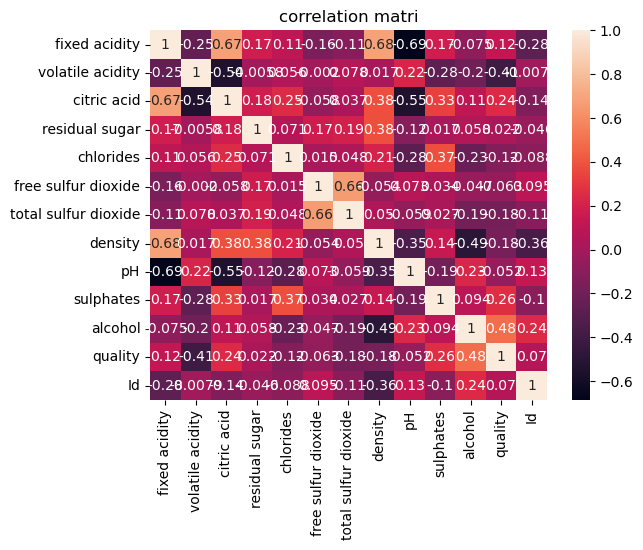

In [23]:
#3.visualization
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.heatmap(df.corr(),annot=True)
plt.title("correlation matri")
plt.show()

In [24]:
#4.prepare data
from sklearn.model_selection import train_test_split

#traget column=quality
x=df.drop('quality',axis=1)
y=df['quality']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [25]:
#5.randomforest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf=RandomForestClassifier()
rf.fit(x_train,y_train)

y_pred_r=rf.predict(x_test)
print("accuracy:",accuracy_score(y_test,y_pred_r))

accuracy: 0.6768558951965066


In [26]:
#6.svm
from sklearn.svm import SVC

svm=SVC()
svm.fit(x_train,y_train)

y_pred_s=svm.predict(x_test)

print("accuracy:",accuracy_score(y_test,y_pred_s))

accuracy: 0.49344978165938863


In [27]:
#7.SGD classifier
from sklearn.linear_model import SGDClassifier

sgd=SGDClassifier(max_iter=1000)
sgd.fit(x_train,y_train)

y_pred_sgd=sgd.predict(x_test)

print("accuracy:",accuracy_score(y_test,y_pred_sgd))

accuracy: 0.39737991266375544


In [28]:
#compare models
print("RF:",accuracy_score(y_test,y_pred_r))
print("SVM:",accuracy_score(y_test,y_pred_s))
print("SGD:",accuracy_score(y_test,y_pred_sgd))


RF: 0.6768558951965066
SVM: 0.49344978165938863
SGD: 0.39737991266375544
